In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
os.getcwd()

'/Users/chance/Desktop/Project/LH_home'

In [3]:
folder = os.listdir('./raw')

file = []
for f in folder:
    if "all" in f:
        data = pd.read_csv("./raw/" + f, encoding="cp949", skiprows=15)
        data = data[list(data.columns[:11])]
        file.append(data)
    
all = pd.concat(file)
all = all.dropna(axis=0)
all

,시군구,번지,도로조건,계약면적(㎡),전월세구분,계약년월,계약일,보증금(만원),월세(만원),건축년도,도로명
0,경상남도 진주시 가좌동,1***,25m미만,12.00,월세,201902,16,200,35,2016.0,가좌길74번길
1,경상남도 진주시 가좌동,1***,8m미만,12.00,전세,201901,5,"4,500",0,2016.0,가좌길78번길
4,경상남도 진주시 가좌동,1***,8m미만,14.20,월세,201906,25,300,32,2016.0,가좌길60번길
5,경상남도 진주시 가좌동,1***,12m미만,14.85,월세,201902,20,500,35,2019.0,가좌길64번길
6,경상남도 진주시 가좌동,1***,12m미만,14.85,월세,201908,28,500,35,2019.0,가좌길64번길
...,...,...,...,...,...,...,...,...,...,...,...
3568,경상남도 진주시 호탄동,6**,8m미만,99.00,월세,202203,14,300,50,2003.0,호탄길27번길
3569,경상남도 진주시 호탄동,6**,8m미만,100.00,월세,202202,13,500,50,2003.0,호탄길14번길
3570,경상남도 진주시 호탄동,6**,8m미만,106.76,전세,202205,6,"14,000",0,2018.0,호탄길9번길
3571,경상남도 진주시 호탄동,6**,25m미만,107.76,월세,202210,19,"9,000",10,2004.0,호탄길


In [4]:
all.도로조건.value_counts()

도로조건
12m미만    7750
8m미만     6668
25m미만    1620
25m이상     243
-          80
Name: count, dtype: int64

In [5]:
geo = pd.read_csv("./raw/geocoding.csv")
all["경도"] = geo.X
all["위도"] = geo.Y

# all = all.fillna({'건축년도':all['건축년도'].mode()[0]})
# all = all.fillna({'도로명':all['도로명'].mode()[0]})
# all = all.fillna({'도로조건':all['도로조건'].mode()[0]})

# 도로조건을 정수로 변환
road=[]
for a in all["도로조건"]:
    if a=="-":
        a = "0"
    if a=="25m이상":
        a = "30"
    road.append(int(str(a).split("m")[0]))
all["도로조건"] = road


# 년월 column 생성
year=[]
month=[]
for d in all["계약년월"]:
    day = pd.to_datetime(d, format="%Y%m")
    year.append(day.year)
    month.append(day.month)

all["year"] = year
all["month"] = month

built_day = [pd.to_datetime(d, format="%Y").year for d in all["건축년도"]]
all["건축년도"] = built_day

# 위치 column만들기
all["location"] = all.시군구 + " " + all.도로명

# 계약년월 기준으로 전월세전환율 입력하기
rate = pd.read_csv("./raw/rate.csv", encoding="cp949")
rate = rate.T
rate = rate[3:]

month = []
for r in rate.index:
    new = "".join(r.split("."))
    month.append(int(new))

rate["계약년월"] = month
rate.columns = ["전월세전환율", "계약년월"]
rate.head()

all = pd.merge(all, rate, how="inner", on="계약년월")

keep = [int("".join(str(k).split(","))) for k in all["보증금(만원)"]]
all["보증금(만원)"] = keep


# 전월세전환율 기준으로 보증금+월세의 가치를 전세로 치환하여 value column으로 만들어준다.
value=[round(all["월세(만원)"][i] * 12 / (all["전월세전환율"][i]/100) + all["보증금(만원)"][i]) for i in range(len(all))]
all["전세전환가격"] = value
#all["도로별 전세값평균"] = all.groupby("도로명").전세전환가격.transform("mean")


# 도로명 결측치 제거
indexNames = []
for i in range(len(all["도로명"])):
    if "번길" not in all["도로명"][i]:
        indexNames.append(i)

all.drop(indexNames, inplace=True)

covid = []
for c in all.year:
    if c in [2020, 2021]:
        covid.append(1)
    else:
        covid.append(0)
all["coivd"] = covid

all["price_per_m2"] = all.전세전환가격 / all["계약면적(㎡)"]
all.head(2)

,시군구,번지,도로조건,계약면적(㎡),전월세구분,계약년월,계약일,보증금(만원),월세(만원),건축년도,도로명,경도,위도,year,month,location,전월세전환율,전세전환가격,coivd,price_per_m2
0,경상남도 진주시 가좌동,1***,25,12.0,월세,201902,16,200,35,2016,가좌길74번길,128.105889,35.157466,2019,2,경상남도 진주시 가좌동 가좌길74번길,5.1,8435,0,702.916667
1,경상남도 진주시 가좌동,1***,8,12.0,전세,201901,5,4500,0,2016,가좌길78번길,128.105889,35.157466,2019,1,경상남도 진주시 가좌동 가좌길78번길,5.3,4500,0,375.000000


## 지도

In [6]:
import math as m

def distance(x1, x2, y1, y2):
    radius = 6371 # 지구 반지름(km)
    toRadian = m.pi / 180

    deltaLatitude = abs(x1 - x2) * toRadian
    deltaLongitude = abs(y1 - y2) * toRadian

    sinDeltaLat = m.sin(deltaLatitude / 2)
    sinDeltaLng = m.sin(deltaLongitude / 2)
    squareRoot = m.sqrt(sinDeltaLat * sinDeltaLat + m.cos(x1 * toRadian) * m.cos(x2 * toRadian) * sinDeltaLng * sinDeltaLng)

    distance = 2 * radius * m.asin(squareRoot)

    return distance

In [7]:
gnu_lat = 35.1530444
gnu_long = 128.1010899

gnu_dist = []
for long, lat in zip(all["경도"], all["위도"]):
    d = distance(gnu_lat, lat, gnu_long, long)
    gnu_dist.append(d)
all["gnu_distance"] = gnu_dist

# all["gnu_distance_per_m2"] = all.gnu_distance / all["계약면적(㎡)"]

## 데이터 시각화

In [8]:
matplotlib.rcParams['font.family'] ='Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] =False

sns.set(font="Malgun Gothic", 
        rc={"axes.unicode_minus":False},)

In [9]:
def remove_out(dataframe, remove_col):
    dff = dataframe
    for k in remove_col:
        level_1q = dff[k].quantile(0.25)
        level_3q = dff[k].quantile(0.7)
        IQR = level_3q - level_1q
        rev_range = 3  # 제거 범위 조절 변수
        dff = dff[(dff[k] <= level_3q + (rev_range * IQR)) & (dff[k] >= level_1q - (rev_range * IQR))]
        dff = dff.reset_index(drop=True)
    return dff

all = remove_out(all, ["gnu_distance"])

all.head(2)

,시군구,번지,도로조건,계약면적(㎡),전월세구분,계약년월,계약일,보증금(만원),월세(만원),건축년도,...,경도,위도,year,month,location,전월세전환율,전세전환가격,coivd,price_per_m2,gnu_distance
0,경상남도 진주시 가좌동,1***,25,12.0,월세,201902,16,200,35,2016,...,128.105889,35.157466,2019,2,경상남도 진주시 가좌동 가좌길74번길,5.1,8435,0,702.916667,0.657356
1,경상남도 진주시 가좌동,1***,8,12.0,전세,201901,5,4500,0,2016,...,128.105889,35.157466,2019,1,경상남도 진주시 가좌동 가좌길78번길,5.3,4500,0,375.000000,0.657356


In [ ]:
sns.scatterplot(data = all, x = "계약면적(㎡)", y = "전세전환가격", hue = "전월세구분")
# sns.lmplot(data = all, x = "계약면적(㎡)", y = "전세전환가격")
m, b = np.polyfit(all["계약면적(㎡)"] , all["전세전환가격"], 1)
plt.plot(all["계약면적(㎡)"], m * all["계약면적(㎡)"] + b, color = "red")
plt.show()

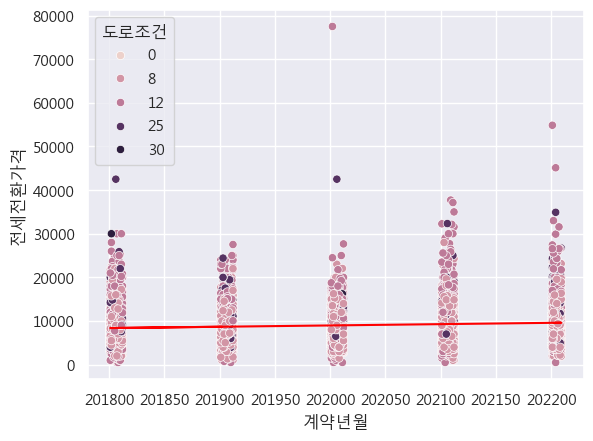

In [11]:
sns.scatterplot(data = all, x = "계약년월", y = "전세전환가격", hue = "도로조건")
m, b = np.polyfit(all["계약년월"] , all["전세전환가격"], 1)
plt.plot(all["계약년월"], m * all["계약년월"] + b, color = "red")
plt.show()

In [12]:
# area = []

# for long, lat in zip(all["경도"],all["위도"]) :
#     if 128.102554 < long < 128.107094 and 35.155823 < lat < 35.162156 :
#         area.append('후문')
#     elif 128.107502 < long < 128.116019 and 35.155877 < lat < 35.158884 :
#         area.append('경찰서')
#     elif 128.105510 < long < 128.109887 and 35.152340 < lat <35.155835 :
#         area.append('정문')
#     elif 128.099328 < long < 128.105970 and 35.14718 < lat < 35.151686 :
#         area.append('남문')
#     elif 128.102356 < long < 128.118509 and 35.161807 < lat < 35.166844 :
#         area.append('호탄')
#     elif 128.107524 < long < 128.118378 and 35.159442 < lat < 35.161644 :
#         area.append('호탄')
#     else :
#         area.append('그 외')

# all["area"] = area
# all

In [13]:
import folium

m = folium.Map(location=[gnu_lat, gnu_long], zoom_start=14)

for lo, la, in zip(all.경도, all.위도):
    folium.Marker([la, lo]).add_to(m)

m

In [14]:
m = folium.Map(location=[all.위도.max(),all.경도.min()], zoom_start=16)
folium.Marker([all.위도.max(),all.경도.min()]).add_to(m)
m

In [15]:
# 전세 월세 구분 데이터셋
# all = all[all.전월세구분 == "월세"]
# all = pd.DataFrame.drop(all, columns=["전월세구분"], axis=1)

#원핫인코딩
all = pd.get_dummies(all, columns = ["전월세구분"])


all.head(2)

,시군구,번지,도로조건,계약면적(㎡),계약년월,계약일,보증금(만원),월세(만원),건축년도,도로명,...,year,month,location,전월세전환율,전세전환가격,coivd,price_per_m2,gnu_distance,전월세구분_월세,전월세구분_전세
0,경상남도 진주시 가좌동,1***,25,12.0,201902,16,200,35,2016,가좌길74번길,...,2019,2,경상남도 진주시 가좌동 가좌길74번길,5.1,8435,0,702.916667,0.657356,True,False
1,경상남도 진주시 가좌동,1***,8,12.0,201901,5,4500,0,2016,가좌길78번길,...,2019,1,경상남도 진주시 가좌동 가좌길78번길,5.3,4500,0,375.000000,0.657356,False,True


In [16]:
all_data = pd.DataFrame.drop(all, columns=["시군구","계약년월", "번지", "도로명", "계약일", "보증금(만원)", "월세(만원)", "location", "경도", "위도", "gnu_distance", "전월세전환율"], axis=1)

#all_data.distance = all_data.distance.transform(lambda x: (x - x.mean()) / x.std())
#all_data.전세전환가격 = all_data.전세전환가격.transform(lambda x: (x - x.mean()) / x.std())
all_data

,도로조건,계약면적(㎡),건축년도,year,month,전세전환가격,coivd,price_per_m2,전월세구분_월세,전월세구분_전세
0,25,12.00,2016,2019,2,8435,0,702.916667,True,False
1,8,12.00,2016,2019,1,4500,0,375.000000,False,True
2,8,14.20,2016,2019,6,7545,0,531.338028,True,False
3,12,14.85,2019,2019,2,8735,0,588.215488,True,False
4,12,14.85,2019,2019,8,8136,0,547.878788,True,False
...,...,...,...,...,...,...,...,...,...,...
13202,8,95.91,2010,2022,5,19558,0,203.920342,True,False
13203,8,99.00,2003,2022,3,14253,0,143.969697,True,False
13204,8,100.00,2003,2022,2,14453,0,144.530000,True,False
13205,8,106.76,2018,2022,5,14000,0,131.135257,False,True


In [29]:
all_data.to_csv('./data/final.csv')

In [28]:
import optuna
from optuna.samplers import TPESampler

# random sampler
sampler = TPESampler(seed=10)

# define function
def objective(trial):

    param = {
        'objective': 'regression',
        'verbose': -1,
        'metric': 'rmse', 
        'num_leaves': trial.suggest_int('num_leaves', 2, 1024, step=1, log=True), 
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.7, 1.0),
        'reg_alpha': trial.suggest_uniform('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_uniform('reg_lambda', 0.0, 10.0),
        'max_depth': trial.suggest_int('max_depth',3, 15),
        'learning_rate': trial.suggest_loguniform("learning_rate", 1e-8, 1e-2),
        'n_estimators': trial.suggest_int('n_estimators', 100, 3000),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_loguniform('subsample', 0.4, 1),
    }

    # Generate model
    lgbm = lgb.LGBMRegressor(**param)
    lgbm = lgbm.fit(X_train, y_train, eval_set=[(X_test, y_test)], 
                           verbose=0, early_stopping_rounds=25)

    # xgboost = XGBRegressor(**param)
    # xgboost.fit(X_train, y_train, eval_set=[(X_test, y_test)], 
    #                        verbose=0, early_stopping_rounds=25)


    # * 평기 지표이다.
    # 원하는 평가 지표에 따라 사용하면 된다.                         
    # MSE = mean_squared_error(y_test, lgbm.predict(X_test))
    # return MSE
    # rmse = mean_squared_error(y_test, lgbm.predict(X_test), squared=False)
    rmse = mean_squared_error(y_test, lgbm.predict(X_test), squared=False)
    return rmse

    # r2 = r2_score(y_test, lgbm.predict(X_test)
    # return r2

study = optuna.create_study(direction='minimize', sampler=sampler)

# * n_trials의 경우 optuna를 몇번 실행하여 hyper parameter를 찾을 것인지를 정한다.
# 50으로 설정해도 유의미한 값이 나온다.
study.optimize(objective, n_trials=100)

ModuleNotFoundError: No module named 'optuna'

In [ ]:
optuna.visualization.plot_param_importances(study)

In [ ]:
trial = study.best_trial
trial_params = trial.params
print('Best Trial: score {},\nparams {}'.format(trial.value, trial_params))

Best Trial: score 51.19772354034532,
params {'num_leaves': 17, 'colsample_bytree': 0.9818632165046602, 'reg_alpha': 0.9504774976734625, 'reg_lambda': 0.026111984951025513, 'max_depth': 9, 'learning_rate': 0.005387804181200352, 'n_estimators': 1065, 'min_child_samples': 9, 'subsample': 0.5900490382283101}


In [ ]:
final_model = lgb.LGBMRegressor(**trial_params)
# final_model = XGBRegressor(**trial_params)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
r2

0.8068294265157188

최종점수 : 0.8091969246246243

<AxesSubplot:title={'center':'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

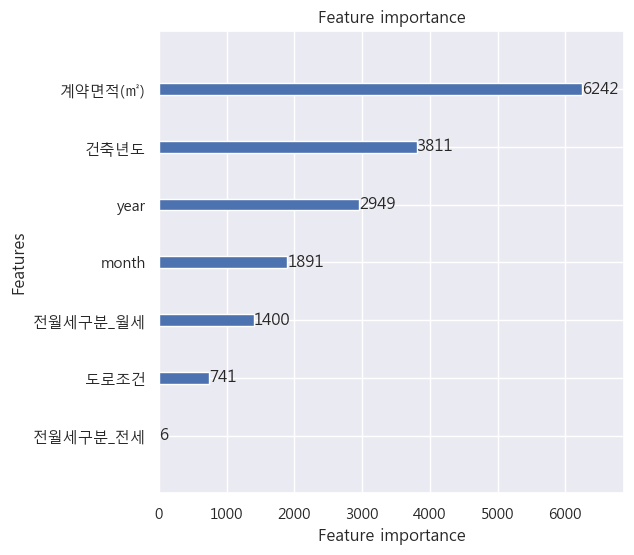

In [ ]:
fig, ax = plt.subplots(figsize =(6,6))
plot_importance(final_model, ax=ax)

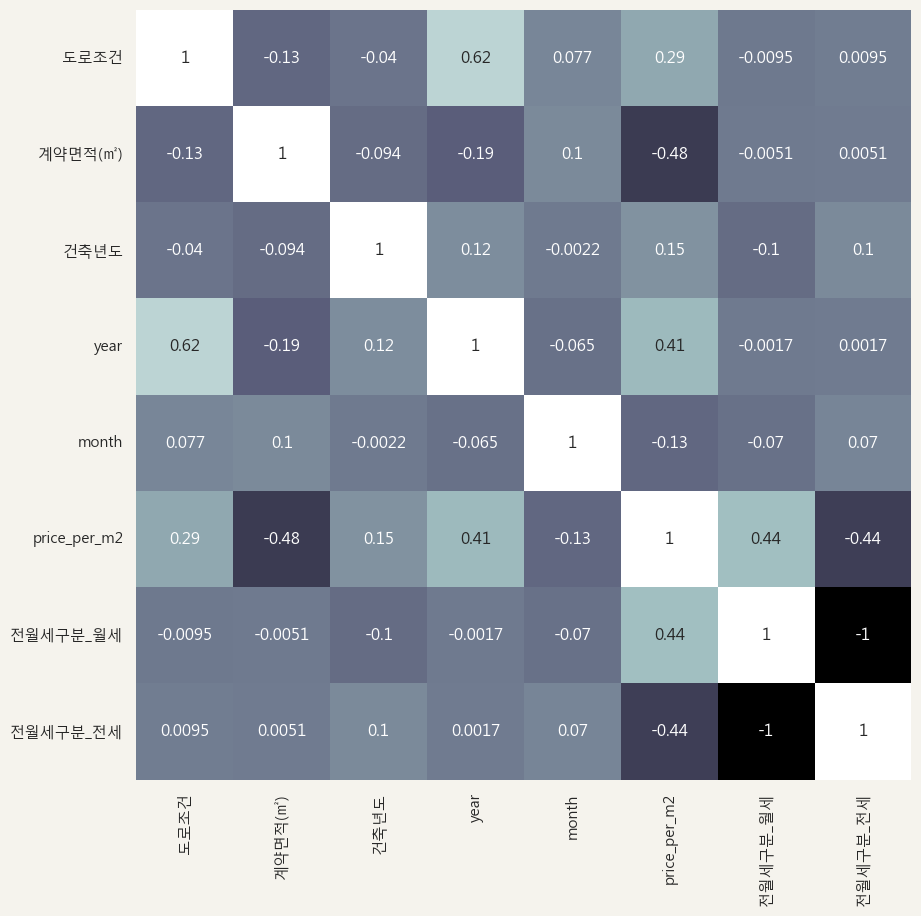

In [ ]:
corr = gajwa_data.corr()
plt.figure(figsize = (10, 10), facecolor = "#F5F3ED")
sns.heatmap(corr, annot = True, cbar = False,cmap = "bone")
plt.show()

In [ ]:
X_test

,도로조건,계약면적(㎡),건축년도,year,month,전월세구분_월세,전월세구분_전세
2,8,16.0,2016,2019,2,0,1
860,8,33.0,2013,2016,12,1,0
1413,0,25.0,2012,2013,8,1,0
381,0,25.0,2007,2015,1,1,0
264,12,28.0,2006,2020,3,1,0
...,...,...,...,...,...,...,...
1561,0,33.0,2007,2012,11,1,0
604,12,16.0,2016,2016,2,1,0
1668,12,35.0,2011,2018,1,1,0
144,8,20.0,2015,2020,1,0,1


In [ ]:
y = X_test.columns
x = [8, 28, 1977, 2022, 12, 1, 0]

x = pd.DataFrame(x, y)
x = x.T

In [ ]:
y

Index(['도로조건', '계약면적(㎡)', '건축년도', 'year', 'month', '전월세구분_월세', '전월세구분_전세'], dtype='object')

In [ ]:
final_model.predict(x) * 28

array([8128.62848972])

In [ ]:
final_model

LGBMRegressor(colsample_bytree=0.9818632165046602,
              learning_rate=0.005387804181200352, max_depth=9,
              min_child_samples=9, n_estimators=1065, num_leaves=17,
              reg_alpha=0.9504774976734625, reg_lambda=0.026111984951025513,
              subsample=0.5900490382283101)

In [ ]:
final_model.booster_.save_model('./txt_data/lh_home.txt')

In [ ]:
load_model = lgb.Booster(model_file='./txt_data/lh_home.txt')
load_model.predict(x) * 28

array([8128.62848972])

In [ ]:
import pandas as pd

def predict():
    load_model = lgb.Booster(model_file='./txt_data/lh_home.txt')

    road = int(input("도로조건을 입력하세요 : "))
    m2 = int(input("거주면적을 입력하세요 : "))
    built = int(input("건축년도를 입력하세요 : "))
    year = int(input("계약년도를 입력하세요 : "))
    month = int(input("계약월을 입력하세요 : "))
    deposit = int(input("보증금을 입력하세요 : (만원)"))
    rate = 6
    
    x = [road, m2, built, year, month, 1, 0]

    y = [['도로조건', '계약면적(㎡)', '건축년도', 'year', 'month', '전월세구분_월세', '전월세구분_전세']]
    data = pd.DataFrame(x, y)
    data = data.T

    load_model = lgb.Booster(model_file='./lh_home.txt')
    price = load_model.predict(data) * m2
    pred = (price - deposit) * rate / 1200
    return pred

In [ ]:
print(predict())

array([39.14314245])